In [ ]:
# Install the core simulator, dataset libraries, and the Colab display utility
!pip install --upgrade ai2thor prior ai2thor_colab

!pip install -q --upgrade ai2thor ai2thor_colab prior
# Install the vision models required by the Perception Agent
!pip install --upgrade ultralytics transformers

In [ ]:
import os
import shutil
import torch
import prior
from ai2thor.controller import Controller
from PIL import Image
from ultralytics import YOLO
from ultralytics.data.annotator import auto_annotate
from IPython.display import display, clear_output
import time

class PerceptionAgent:
    def __init__(self, yolo_weights="yolo11m.pt", sam_weights="sam2-b.pt", save_dir="saved_agent_data"):
        self.yolo_weights = yolo_weights
        self.sam_weights = sam_weights
        self.save_dir = save_dir

        if torch.cuda.is_available():
            self.device = "cuda"
        else:
            self.device = "cpu"

        print(f"[PerceptionAgent] Initializing with device: {self.device}")

        self.yolo = YOLO(self.yolo_weights)
        self.yolo.to(self.device)
        self.class_names = self.yolo.names

        # Clean the master directory on startup so old Colab runs don't pile up
        if os.path.exists(self.save_dir):
            shutil.rmtree(self.save_dir)
        os.makedirs(self.save_dir, exist_ok=True)

    def _get_spatial_descriptor(self, polygon_coords) -> str:
        x_coords = polygon_coords[0::2]
        y_coords = polygon_coords[1::2]

        center_x = sum(x_coords) / len(x_coords)
        center_y = sum(y_coords) / len(y_coords)

        horizontal = "center"
        if center_x < 0.33:
            horizontal = "left"
        elif center_x > 0.66:
            horizontal = "right"

        vertical = "center"
        if center_y < 0.33:
            vertical = "top"
        elif center_y > 0.66:
            vertical = "bottom"

        if horizontal == "center" and vertical == "center":
            return "in the center"
        return f"in the {vertical}-{horizontal}"

    def perceive(self, image: Image.Image, frame_name: str) -> str:
        """
        Runs perception and saves the image and mask data into a persistent folder.
        """
        # Create an isolated directory just for this specific step
        step_dir = os.path.join(self.save_dir, frame_name)
        os.makedirs(step_dir, exist_ok=True)

        # Save the original image
        img_path = os.path.join(step_dir, "frame.jpg")
        image.save(img_path)

        # Trigger native auto_annotate
        # By setting data and output_dir to the same folder, it places the
        # YOLO bounding boxes and SAM masks (.txt) right next to the .jpg
        auto_annotate(
            data=step_dir,
            det_model=self.yolo_weights,
            sam_model=self.sam_weights,
            output_dir=step_dir,
            device=self.device
        )

        label_file = os.path.join(step_dir, "frame.txt")

        if not os.path.exists(label_file):
            return "No distinct objects are visible in the current view."

        description_lines = ["Visible Objects (Segmented):"]

        with open(label_file, "r") as f:
            lines = f.readlines()
            for line in lines:
                parts = line.strip().split()
                if not parts:
                    continue

                class_id = int(parts[0])
                class_name = self.class_names.get(class_id, "unknown object")

                polygon_coords = [float(x) for x in parts[1:]]

                if len(polygon_coords) >= 2:
                    spatial_loc = self._get_spatial_descriptor(polygon_coords)

                    width = max(polygon_coords[0::2]) - min(polygon_coords[0::2])
                    height = max(polygon_coords[1::2]) - min(polygon_coords[1::2])
                    area_ratio = width * height

                    description_lines.append(f"- {class_name} located {spatial_loc}, covering roughly {area_ratio:.1%} of the view.")

        # Clear GPU cache to prevent OOM errors over the loop
        if self.device == "cuda":
            torch.cuda.empty_cache()

        return "\n".join(description_lines)



[AI2-THOR WARNING] There has been an update to ProcTHOR-10K that must be used with AI2-THOR version 5.0+. To use the new version of ProcTHOR-10K, please update AI2-THOR to version 5.0+ by running:
    pip install --upgrade ai2thor
Alternatively, to downgrade to the old version of ProcTHOR-10K, run:
   prior.load_dataset("procthor-10k", revision="ab3cacd0fc17754d4c080a3fd50b18395fae8647")


Loading test: 100%|██████████| 1000/1000 [00:00<00:00, 5513.47it/s]


In [12]:
# Run this in its own cell and let it finish completely
from ai2thor.controller import Controller
import prior

dataset = prior.load_dataset("procthor-10k")
house = dataset["train"][0]
controller = Controller(scene=house)

[AI2-THOR WARNING] There has been an update to ProcTHOR-10K that must be used with AI2-THOR version 5.0+. To use the new version of ProcTHOR-10K, please update AI2-THOR to version 5.0+ by running:
    pip install --upgrade ai2thor
Alternatively, to downgrade to the old version of ProcTHOR-10K, run:
   prior.load_dataset("procthor-10k", revision="ab3cacd0fc17754d4c080a3fd50b18395fae8647")


Loading test: 100%|██████████| 1000/1000 [00:00<00:00, 4241.77it/s]


  Agent Step 8/10 (Turned 105° total)  
Data saved to: /saved_agent_data/step_7/


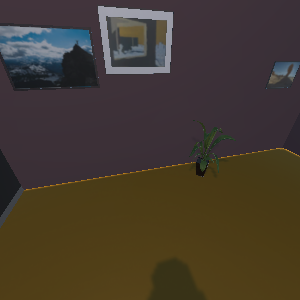


Visible Objects (Segmented):
- person located in the bottom-center, covering roughly 2.6% of the view.
- laptop located in the center-left, covering roughly 1.7% of the view.

image 1/1 /content/saved_agent_data/step_8/frame.jpg: 640x640 1 person, 1 potted plant, 1985.2ms


In [ ]:



perception_agent = PerceptionAgent(yolo_weights="yolo11m.pt", sam_weights="sam2_b.pt")

total_steps = 10
degrees_per_step = 15

for step in range(total_steps):
    if step > 0:
        event = controller.step(action="RotateRight", degrees=degrees_per_step)
    else:
        event = controller.last_event

    current_frame = Image.fromarray(event.frame)

    # Pass a unique identifier (e.g., "step_0") to save the data permanently
    step_id = f"step_{step}"
    scene_description = perception_agent.perceive(current_frame, frame_name=step_id)

    clear_output(wait=True)
    print(f"======================================")
    print(f"  Agent Step {step + 1}/{total_steps} (Turned {step * degrees_per_step}° total)  ")
    print(f"======================================")
    print(f"Data saved to: /saved_agent_data/{step_id}/")

    display(current_frame)
    print("\n" + scene_description)
    time.sleep(0.5)

print("\n[Sequence Complete. All masks and boxes are saved in the 'saved_agent_data' folder.]")